# Sentiment Analysis using NLP Pipeline & ML Models

## Objective
Build an end-to-end sentiment analysis system using preprocessing, feature engineering (BoW & TF-IDF), and ML models. Compare performance using evaluation metrics.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [35]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [36]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [37]:
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['sentiment'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (50000, 2)

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing Values:
 review       0
sentiment    0
dtype: int64


In [38]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)   # remove HTML
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['review'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [39]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})
y = df['sentiment']

In [40]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [41]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text'])

In [42]:
# TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# BoW
X_train_bow, X_test_bow, _, _ = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

In [43]:
# TF-IDF Models
lr = LogisticRegression()
nb = MultinomialNB()
dt = DecisionTreeClassifier()

lr.fit(X_train_tfidf, y_train)
nb.fit(X_train_tfidf, y_train)
dt.fit(X_train_tfidf, y_train)

# BoW Models
lr_bow = LogisticRegression()
nb_bow = MultinomialNB()
dt_bow = DecisionTreeClassifier()

lr_bow.fit(X_train_bow, y_train)
nb_bow.fit(X_train_bow, y_train)
dt_bow.fit(X_train_bow, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier()

In [44]:
def evaluate(model, X_test):
    y_pred = model.predict(X_test)
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

In [45]:
results = pd.DataFrame({
    'Model': ['LR (TF-IDF)', 'NB (TF-IDF)', 'DT (TF-IDF)',
              'LR (BoW)', 'NB (BoW)', 'DT (BoW)'],

    'Accuracy': [
        evaluate(lr, X_test_tfidf)[0],
        evaluate(nb, X_test_tfidf)[0],
        evaluate(dt, X_test_tfidf)[0],
        evaluate(lr_bow, X_test_bow)[0],
        evaluate(nb_bow, X_test_bow)[0],
        evaluate(dt_bow, X_test_bow)[0]
    ],

    'Precision': [
        evaluate(lr, X_test_tfidf)[1],
        evaluate(nb, X_test_tfidf)[1],
        evaluate(dt, X_test_tfidf)[1],
        evaluate(lr_bow, X_test_bow)[1],
        evaluate(nb_bow, X_test_bow)[1],
        evaluate(dt_bow, X_test_bow)[1]
    ],

    'Recall': [
        evaluate(lr, X_test_tfidf)[2],
        evaluate(nb, X_test_tfidf)[2],
        evaluate(dt, X_test_tfidf)[2],
        evaluate(lr_bow, X_test_bow)[2],
        evaluate(nb_bow, X_test_bow)[2],
        evaluate(dt_bow, X_test_bow)[2]
    ],

    'F1 Score': [
        evaluate(lr, X_test_tfidf)[3],
        evaluate(nb, X_test_tfidf)[3],
        evaluate(dt, X_test_tfidf)[3],
        evaluate(lr_bow, X_test_bow)[3],
        evaluate(nb_bow, X_test_bow)[3],
        evaluate(dt_bow, X_test_bow)[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,LR (TF-IDF),0.8848,0.875991,0.898591,0.887147
1,NB (TF-IDF),0.8492,0.847608,0.854336,0.850959
2,DT (TF-IDF),0.7184,0.724591,0.711649,0.718062
3,LR (BoW),0.8724,0.868560,0.879936,0.874211
4,NB (BoW),0.8463,0.850761,0.842826,0.846775
5,DT (BoW),0.7182,0.721436,0.718000,0.719714


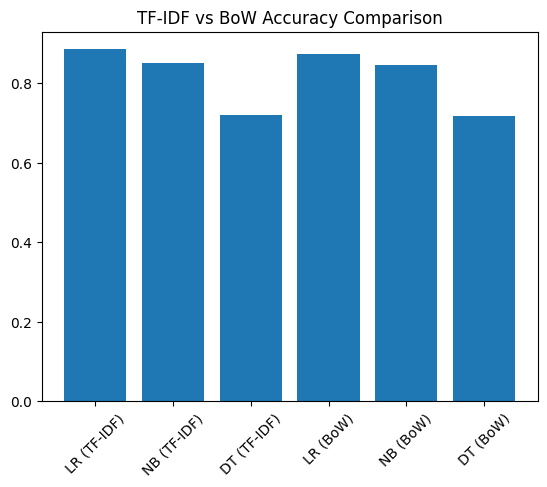

In [46]:
plt.figure()
plt.bar(results['Model'], results['Accuracy'])
plt.xticks(rotation=45)
plt.title("TF-IDF vs BoW Accuracy Comparison")
plt.show()

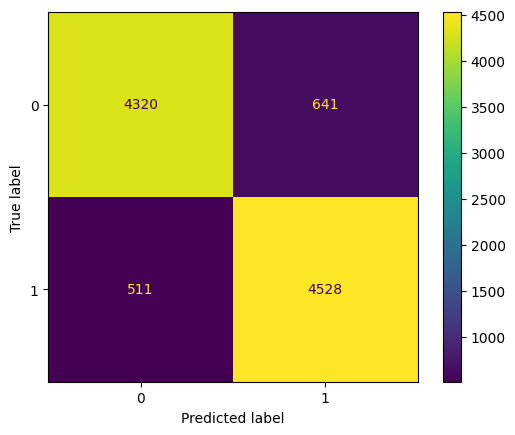

In [47]:
y_pred = lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Pipeline Flow

Raw Data → Cleaning → Tokenization → Lemmatization → Feature Engineering (TF-IDF, BoW) → Model Training → Evaluation → Comparison

## Insights

- TF-IDF performed better than BoW because it assigns importance to meaningful words.
- Logistic Regression achieved the highest accuracy among all models.
- Naive Bayes performed well due to probabilistic assumptions.
- Decision Tree showed lower performance due to overfitting.

## Conclusion

TF-IDF + Logistic Regression is the best combination for this dataset.